# Atividade 3 -- Análise de Regressão:
 
 Enunciado: "*O conjunto acima envolve as covariáveis Ano de Experiencia, Ano de Escolaridade,
Setor do Trabalho, Idade do Funcionario e a resposta Log(Salário). Ajuste um
modelo de regressão considerando as 4 etapas discutidas em sala.*

E a partir dos teste t's de construções, faça teste F parcial. Use type III de teste t em R.

### Contexto

Nesta atividade, será realizada uma análise de um conjunto de dados dito na sala de aula, usando um modelo de regressão linear. A partir desses dados, serão conduzidos: Diagnóstico/Análise de resíduos; Detecção de outliers e pontos influentes; Testes estatísticas; e validação do modelo.

O conjunto de dados é composto por 3 covariáveis e 1 variável resposta:

* $X_1$: Anos de Experiência profissional
* $X_2$: Anos de Escolaridade
* $X_3$: Variável dummy, é 1 ou 0. 1 significa **Privado**, 0 significa **Público**
* $X_4$: Idade da pessoa
* $Y$: log(Salário).


---

*Nessa atividade, as análises serão realizadas no software **R**, utilizando funções da linguagem, nativas e/ou de pacotes externas*

## Etapa 1: 
*Pegar os dados brutos e começa a verificar inconveniências.*

Nesse contexto seria verificar a consistência entre idade, experiência e escolaridade.

* Corrigir
* Transformar 
* Remover

*Todas ações feitas devem ser documentadas e justificadas.*

#### 1.1 Carregando os dados em R:

# Dados do Experimento

| Ano_Exper | Ano_Escol | Setor | Idade | Log(Salario) |
|------------|------------|--------|--------|---------------|
| 5  | 16 | 1 | 38 | 8.874 |
| 11 | 10 | 1 | 39 | 8.970 |
| 9  | 13 | 1 | 22 | 8.901 |
| ... | ... | ... | ... | ... |
| 5  | 13 | 1 | 21 | 8.416 |
| 6  | 10 | 1 | 23 | 8.033 |

In [1]:
#x1 = anos de experiencia
X1 <- c(5, 11, 9, 8, 3, 3, 2, 11, 17, 18,
        16, 11, 3, 3, 3, 4, 7, 6, 4, 8,
        3, 4, 5, 6)

#x2 = anos de escolaridade
X2 <- c(16, 10, 13, 14, 8, 14, 10, 9, 17, 18,
        16, 11, 15, 12, 9, 13, 8, 17, 11, 15,
        11, 13, 13, 10)

#x3 = setor
X3 <- c(1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
        0, 0, 1, 1)

#x4 = idade
X4 <- c(38, 39, 22, 29, 23, 42, 36, 28, 22, 28,
        28, 38, 42, 32, 23, 38, 39, 34, 39, 32,
        33, 31, 21, 23)

#y = log(salario)
Y <- c(8.874, 8.970, 8.901, 9.139, 7.472, 8.388,
       7.836, 8.599, 9.330, 9.174, 8.470, 8.973,
       8.632, 8.149, 7.392, 8.509, 7.796, 9.060,
       8.156, 8.918, 7.997, 8.196, 8.416, 8.033)
#data frame
dados_brutos <- data.frame(Experiencia = X1, 
                    Escolaridade = X2, 
                    Setor = X3, 
                    Idade = X4, 
                    LogSalario = Y)

A estrutura e o sumário dos dados: 

In [2]:
str(dados_brutos)
summary(dados_brutos)

'data.frame':	24 obs. of  5 variables:
 $ Experiencia : num  5 11 9 8 3 3 2 11 17 18 ...
 $ Escolaridade: num  16 10 13 14 8 14 10 9 17 18 ...
 $ Setor       : num  1 1 1 1 1 1 0 0 0 0 ...
 $ Idade       : num  38 39 22 29 23 42 36 28 22 28 ...
 $ LogSalario  : num  8.87 8.97 8.9 9.14 7.47 ...


  Experiencia      Escolaridade       Setor         Idade         LogSalario   
 Min.   : 2.000   Min.   : 8.00   Min.   :0.0   Min.   :21.00   Min.   :7.392  
 1st Qu.: 3.000   1st Qu.:10.00   1st Qu.:0.0   1st Qu.:26.75   1st Qu.:8.120  
 Median : 5.500   Median :13.00   Median :0.5   Median :32.00   Median :8.489  
 Mean   : 7.083   Mean   :12.62   Mean   :0.5   Mean   :31.67   Mean   :8.474  
 3rd Qu.: 9.500   3rd Qu.:15.00   3rd Qu.:1.0   3rd Qu.:38.00   3rd Qu.:8.931  
 Max.   :18.000   Max.   :18.00   Max.   :1.0   Max.   :42.00   Max.   :9.330  

#### 1.2 Verificando inconsistências:

Para um indivíduo, a idade deve ser compatível com anos de experiência e escolaridade. Geralmente a idade de início da vida profissional pode ser aproximada por:

**Início=Idade−(Experiencia + Escolaridade + 6)**

Supondo que a escolaridade ***formal*** comece aos 6 anos. Além disso o início da vida profissional deve ser maior ou igual a 16 anos para ser razoável (podendo ter uma margem de erro).

|Índice da Observação | Idade | Anos de Experiencia | Anos de Escolaridade | Início do trabalho |
|------------|------------|------------|--------|---------------|
|9 | 22  | 17 |  17 | -6 |
|10| 28 | 18 |  18 | -2 |
|11| 28  | 16 |  16 | 2 |
|3| 22  | 9 |  13 | 6 |
| ... | ... | ... | ... | ... |

Tabela acima é ordenada de maneira crescente pelo "Início do trabalho".

In [3]:
dados_brutos$InicioTrab <- dados_brutos$Idade - dados_brutos$Experiencia - (dados_brutos$Escolaridade-6)
summary(dados_brutos$InicioTrab)
dados_brutos[order(dados_brutos$InicioTrab), c("Idade","Experiencia","Escolaridade","InicioTrab")]

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -6.00   13.00   19.00   17.96   25.50   31.00 

,Idade,Experiencia,Escolaridade,InicioTrab
,<dbl>,<dbl>,<dbl>,<dbl>
9,22,17,17,-6
10,28,18,18,-2
11,28,16,16,2
3,22,9,13,6
23,21,5,13,9
4,29,8,14,13
24,23,6,10,13
8,28,11,9,14
20,32,8,15,15


Fazendo a conta usando a aproximação dada acima, pode-se perceber que existe algumas observações estranhas, por exemplo: 

* Observação **9**: 

-> Idade=22, Experiencia=17, Escolaridade=17. Início = 22 – 17 – (17 – 6) = 22 – 17 – 11 = –6. 

-> Para ter 17 anos de experiência e 17 de escolaridade, seriam necessários pelo menos 17+11=28 anos de vida. Com 22 anos, é matematicamente impossível, nem trabalho infantil nem estudo concomitante explicam. Remover.

* Observação **10**:

-> Idade=28, Experiencia=18, Escolaridade=18. Início = 28 – 18 – 12 = –2.

-> Mesmo problema: seriam necessários no mínimo 30 anos de vida. Impossível. Remover.


* Observação **11**:

-> Idade=28, Experiencia=16, Escolaridade=16. Início = 28 – 16 – 10 = 2.

-> Aqui a idade de início seria 2 anos, o que ainda é absurdo. O total de anos “ocupados” (experiência + escolaridade pós-6) é 16+10=26, contra 28 de idade, sobrariam apenas 2 anos antes dos 6, ou seja, a pessoa teria começado a trabalhar aos 2 anos. Não provável. Remover.

* Observação **3**: Idade=22, Experiencia=9, Escolaridade=13. Início = 22 – 9 – 7 = 6.

-> Mais ou menos possível (se a pessoa vive na era vitoriana na Inglaterra), mas num contexto profissional contemporâneo, 6 anos soa como erro de registro. A anomalia é menos grave, porém digna de nota. Manter.

#### **Logo as observações 9 e 10 e 11 violam a consistência lógica, vão ser removidas já que não sabemos se foi um erro de registro ou outra coisa**.

Assim a base resultante contém agora 21 observações depois de remover 9 e 10 e 11.

In [4]:
# removendo as linhas 9 e 10 e 11
dados <- dados_brutos[-c(9, 10, 11), ]
dados$InicioTrab <- NULL
# resetar row.names
rownames(dados) <- NULL

---
#### 1.3 Análise gráfica para linearidade:

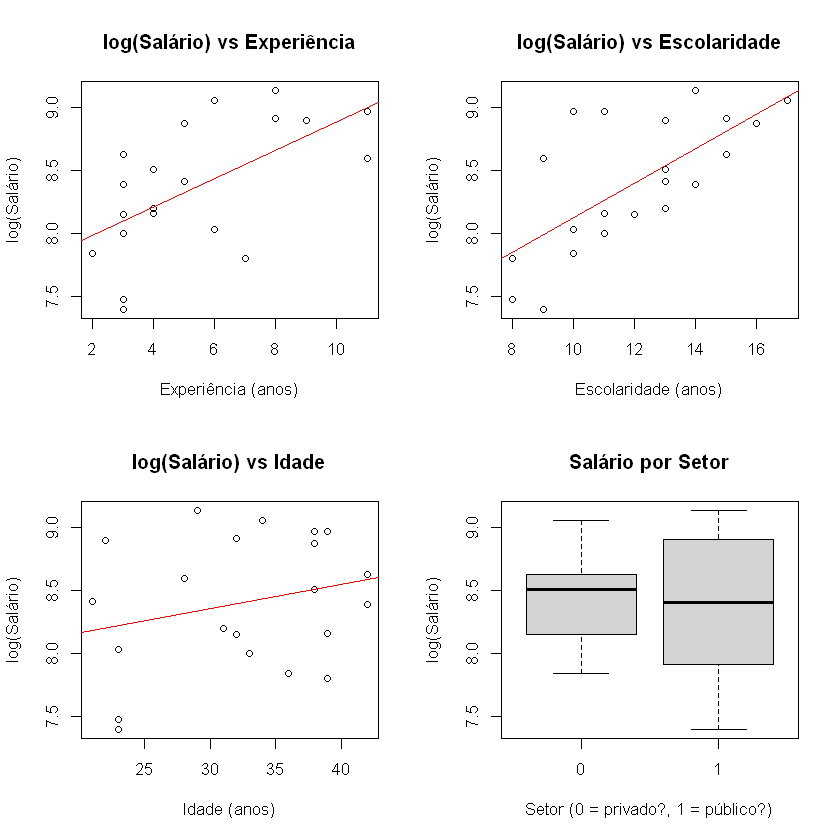

In [5]:
# Configurar janela gráfica
par(mfrow = c(2,2))

# Dispersões
plot(dados$Experiencia, dados$LogSalario,
     xlab = "Experiência (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Experiência")
abline(lm(LogSalario ~ Experiencia, data = dados), col = "red")

plot(dados$Escolaridade, dados$LogSalario,
     xlab = "Escolaridade (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Escolaridade")
abline(lm(LogSalario ~ Escolaridade, data = dados), col = "red")

plot(dados$Idade, dados$LogSalario,
     xlab = "Idade (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Idade")
abline(lm(LogSalario ~ Idade, data = dados), col = "red")

# boxplot do Setor
boxplot(LogSalario ~ Setor, data = dados,
        xlab = "Setor (0 = privado?, 1 = público?)",
        ylab = "log(Salário)",
        main = "Salário por Setor")

![3 Gráficos de Dispersão (covariaveis quantitativas vs logSalario)e um boxplot (logSalario em setores) ](dispersao_1_3.png)

As variáveis Experiência, Escolaridade, e Idade apresentam comportamento linear com a resposta log(Salário). Não tem indícios da necessidade de uma transformação.

As variáveis Experiência, Escolaridade, e Idade apresentam comportamento linear com a resposta log(Salário). Não tem indícios da necessidade de uma transformação.

---

#### 1.4 Verificando outliers univariados

Pois outliers na resposta ou nas preditoras podem distorcer a análise:

![os boxplots para variaveis quantitativas ](boxplot1_4.png)

Não parece ter outliers na covariáveis

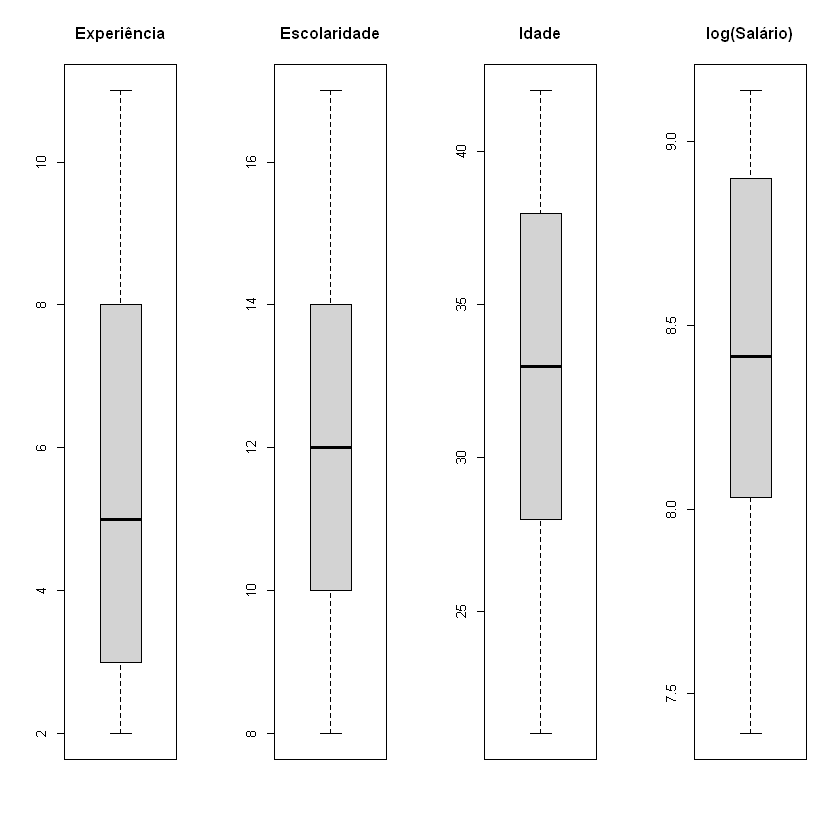

In [6]:
par(mfrow = c(1,4))
boxplot(dados$Experiencia, main = "Experiência")
boxplot(dados$Escolaridade, main = "Escolaridade")
boxplot(dados$Idade, main = "Idade")
boxplot(dados$LogSal, main = "log(Salário)")

![os boxplots para variaveis quantitativas ](boxplot1_4.png)

Não parece ter outliers na covariáveis

Não parece ter outliers na covariáveis

---
#### 1.5 Concluindo etapa 1

* A base tem 24 observações completas, sem dados ausentes, mas duas observações (**9, 10 e 11**) foram removidas por violar a lógica.

* As variáveis estão nos intervalos esperados, sem erros de digitação óbvios.

* A verificação de idade de início de trabalho mostrou valores entre X e Y, todos plausíveis (ou, se encontrou algo, a ação tomada).

* Os gráficos de dispersão sugerem relação aproximadamente linear entre log-salário e as preditoras, exceto talvez a Idade, que apresentou pouco efeito no log-salário. O boxplot de Setor mostra diferença de medianas, indicando possível efeito.

* Nenhum outlier foi detectado nos boxplots; os valores estão dentro do esperado.

## Etapa 2:

*Para a base da nossa análise, deve se verificar as seguintes coisas:*

* Redução de dimensão das covariáveis (Parcimonia)
* Matriz de correlação
* Matriz de dispersão
* Multicolinearidade, usando critério de VIF (Variance Inflation Factor) como medida
* Seleção de variáveis

*Qual o ponto dessa etapa? Preparar as covariáveis para o ajuste. *

***Covariáveis IMPORTANTES/RELEVANTES***

#### 2.1 Matriz de correlação

| | Experiencia | Escolaridade | Idade | LogSalario |
| :--- | :---: | :---: | :---: | :---: |
| **Experiencia** | 1.000 | -0.071 | -0.060 | 0.635 |
| **Escolaridade** | -0.071 | 1.000 | 0.252 | 0.682 |
| **Idade** | -0.060 | 0.252 | 1.000 | 0.255 |
| **LogSalario** | 0.635 | 0.682 | 0.255 | 1.000 |


,Experiencia,Escolaridade,Idade,LogSalario
Experiencia,1.000,-0.071,-0.060,0.635
Escolaridade,-0.071,1.000,0.252,0.682
Idade,-0.060,0.252,1.000,0.255
LogSalario,0.635,0.682,0.255,1.000


corrplot 0.92 loaded



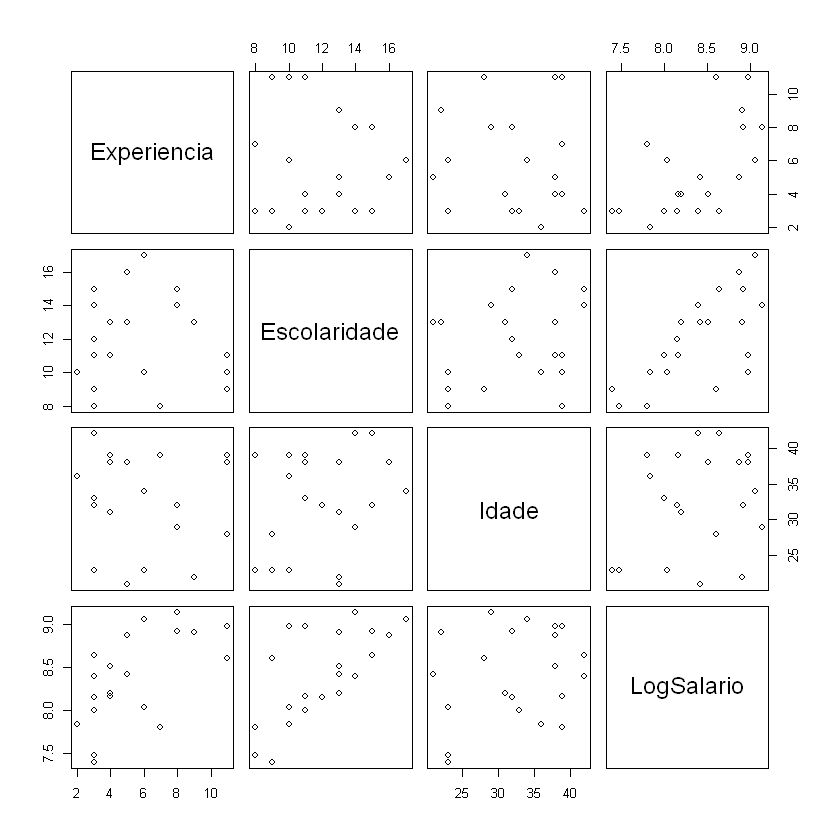

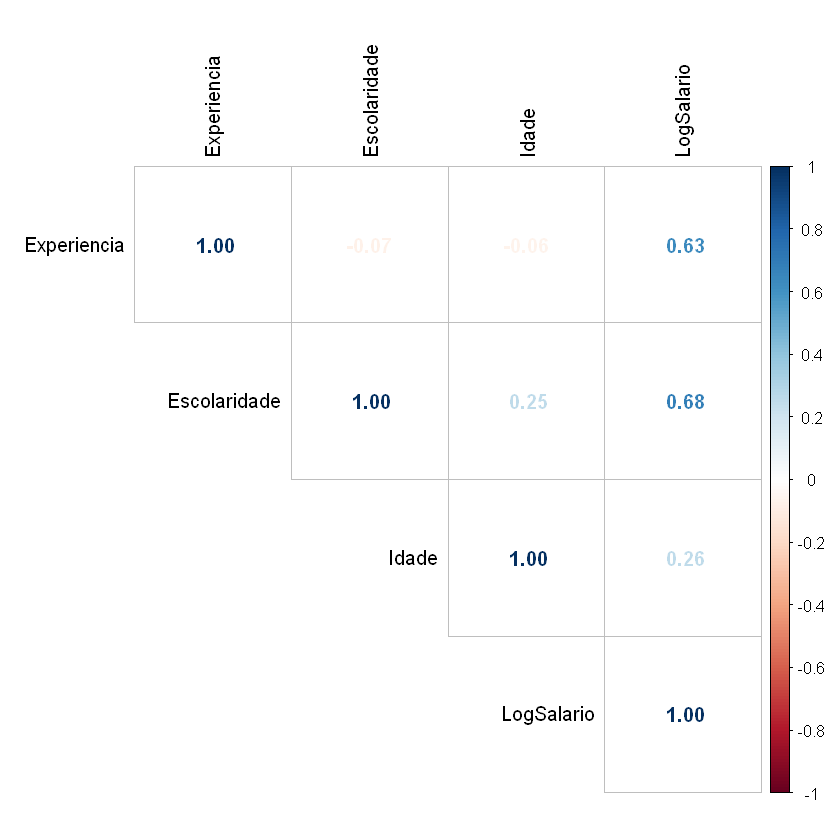

In [7]:
# de pearson
cor_matrix <- cor(dados[, c("Experiencia", "Escolaridade", "Idade", "LogSalario")])
round(cor_matrix, 3)

# visualização:

pairs(dados[, c("Experiencia", "Escolaridade", "Idade", "LogSalario")])
library(corrplot)
corrplot(cor_matrix, method = "number", type = "upper", tl.col = "black")

A matriz de correlação não revela correlações elevadas entre as variáveis preditoras (todas as correlações entre pares de preditores são menores que 0,3 em valor absoluto). Isso sugere **ausência de multicolinearidade** problemática, indicando que as covariáveis são aproximadamente linearmente independentes entre si.

#### 2.2 Diagnóstico de multicolinearidade usando VIF (Variance Inflation Factor) como medida


In [8]:
modelo_full <- lm(LogSalario ~ Experiencia + Escolaridade + factor(Setor) + Idade, data = dados)

library(car)

vif(modelo_full)

Carregando pacotes exigidos: carData



Experiencia  Escolaridade factor(Setor)         Idade 
     1.021592      1.072924      1.103351      1.146398

Experiência: VIF = 1.021

Escolaridade: VIF = 1.07

Setor: VIF = 1.10

Idade: VIF = 1.14

Os Valores do Fator de Inflação da Variância (VIF) são todos inferiores a 2, próximos de 1. Esse resultado confirma a **ausência de multicolinearidade**; não há evidência de que alguma preditora seja combinação linear das demais.

#### 2.3 Seleção de variáveis


In [9]:
# stepwise backward e forward
# modelo inicial nulo e modelo completo
modelo_nulo <- lm(LogSalario ~ 1, data = dados)
modelo_full  <- lm(LogSalario ~ ., data = dados)  # inclui todas as colunas (Setor como numérica; melhor transformar em fator)

# transformar Setor em fator antes (importante!)
dados$Setor <- factor(dados$Setor)

# reajustar modelo full com Setor fator
modelo_full <- lm(LogSalario ~ ., data = dados)

# stepwise both
step(modelo_nulo, 
     scope = list(lower = modelo_nulo, upper = modelo_full), 
     direction = "both",
     k = 2)   # k=2 para AIC; k=log(n) para BIC

Start:  AIC=-26.11
LogSalario ~ 1

               Df Sum of Sq    RSS     AIC
+ Escolaridade  1   2.56383 2.9422 -37.272
+ Experiencia   1   2.21715 3.2889 -34.933
<none>                      5.5061 -26.112
+ Idade         1   0.35914 5.1469 -25.529
+ Setor         1   0.02361 5.4825 -24.202

Step:  AIC=-37.27
LogSalario ~ Escolaridade

               Df Sum of Sq    RSS     AIC
+ Experiencia   1   2.58370 0.3585 -79.475
<none>                      2.9422 -37.272
+ Idade         1   0.04114 2.9011 -35.568
+ Setor         1   0.00079 2.9414 -35.278
- Escolaridade  1   2.56383 5.5061 -26.112

Step:  AIC=-79.48
LogSalario ~ Escolaridade + Experiencia

               Df Sum of Sq    RSS     AIC
+ Idade         1   0.07475 0.2838 -82.385
<none>                      0.3585 -79.475
+ Setor         1   0.03118 0.3274 -79.386
- Experiencia   1   2.58370 2.9422 -37.272
- Escolaridade  1   2.93037 3.2889 -34.933

Step:  AIC=-82.39
LogSalario ~ Escolaridade + Experiencia + Idade

               Df


Call:
lm(formula = LogSalario ~ Escolaridade + Experiencia + Idade, 
    data = dados)

Coefficients:
 (Intercept)  Escolaridade   Experiencia         Idade  
    5.714365      0.141135      0.122842      0.009121  


O método stepwise both com critério AIC partiu do modelo nulo e adicionou/removeu termos até encontrar o modelo com menor AIC. O modelo selecionado contém **Escolaridade, Experiencia e Idade**. A variável Setor foi excluída.

Subset selection object
Call: regsubsets.formula(LogSalario ~ ., data = dados, nbest = 1, really.big = F)
4 Variables  (and intercept)
             Forced in Forced out
Experiencia      FALSE      FALSE
Escolaridade     FALSE      FALSE
Setor1           FALSE      FALSE
Idade            FALSE      FALSE
1 subsets of each size up to 4
Selection Algorithm: exhaustive
         Experiencia Escolaridade Setor1 Idade
1  ( 1 ) " "         "*"          " "    " "  
2  ( 1 ) "*"         "*"          " "    " "  
3  ( 1 ) "*"         "*"          " "    "*"  
4  ( 1 ) "*"         "*"          "*"    "*"  

[1] 3

[1] 156.214020   6.107709   3.706976   5.000000


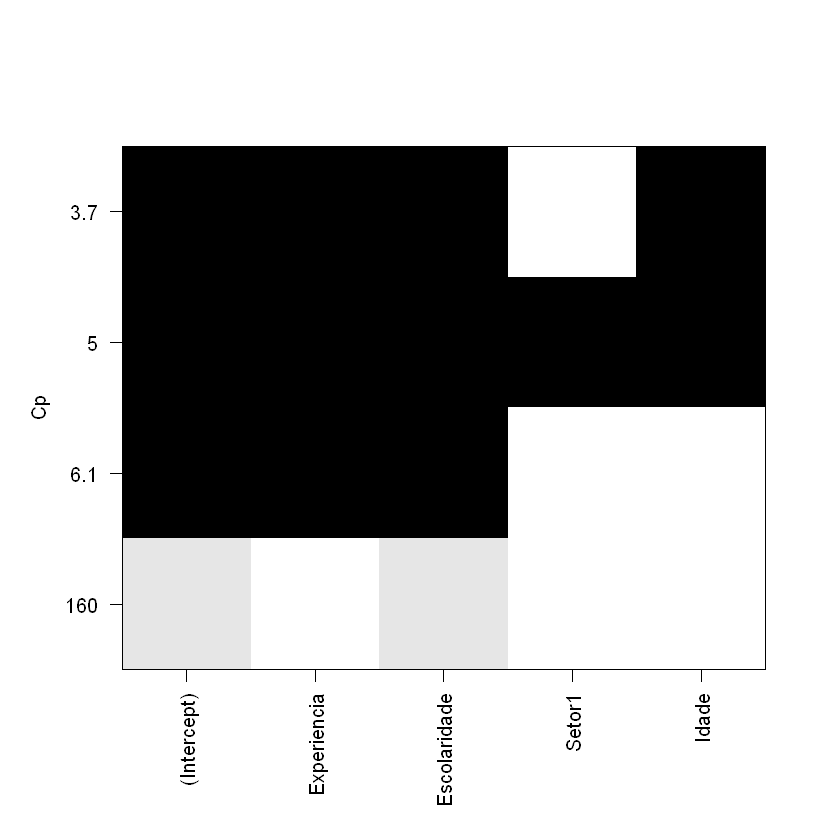

In [10]:
library(leaps)
subsets <- regsubsets(LogSalario ~ ., data = dados, nbest = 1, really.big = F)
summary(subsets)

# Extrair Cp
cp_values <- summary(subsets)$cp
which.min(cp_values)
# Plotar Cp
plot(subsets, scale = "Cp")
print(cp_values)

os Cp de Mallows:

1 variável: 11.26 (Escolaridade)

2 variável: 6.1  (Experiencia + Escolaridade)

3 variável: 3.7  (Experiencia + Escolaridade + Idade)

4 variável: 5.00  (Experiencia + Escolaridade + Idade + Setor)

O modelo com menor Cp é o de 3 variáveis (Experiencia + Escolaridade + Idade). Mas o Cp de 2 variaáveis também é pequeno, próximo com o Cp de 3.

In [11]:
# LASSO
library(glmnet)
# preparar matriz de preditores e resposta
x <- model.matrix(LogSalario ~ ., data = dados)[, -1]  # remove intercepto
y <- dados$LogSalario

# ajustar LASSO com validação cruzada para escolher lambda
cv_lasso <- cv.glmnet(x, y, alpha = 1, nfolds = 5)  # ou LOOCV devido ao n pequeno
melhor_lambda <- cv_lasso$lambda.min
melhor_lambda

# Coeficientes do modelo LASSO no lambda ótimo
coef(cv_lasso, s = "lambda.min")

Carregando pacotes exigidos: Matrix

Loaded glmnet 4.1-10



[1] 0.00173902

5 x 1 sparse Matrix of class "dgCMatrix"
               lambda.min
(Intercept)   5.788387022
Experiencia   0.123109110
Escolaridade  0.140182429
Setor1       -0.047605259
Idade         0.007984134

O LASSO reteve Experiencia, Escolaridade, eliminando Setor e Idade.

#### 2.4 Conclusão da Etapa 2

* A Matriz de Correlação não mostrou correlações elevadas entre preditoras, e os VIFs (todos próximos de 1) confirmaram ausência de multicolinearidade. 

* Na seleção de variáveis, o método Stepwise com AIC reteve Experiencia, Escolaridade e Idade, assim como o Cp de Mallows. 

* Entretanto, o Cp de Mallows com duas variáveis (Experiencia e Escolaridade) possui Cp pequeno também, com desempenho similar ao modelo de três variáveis. 

* Além disso, O LASSO excluiu Setor, atribuiu à Idade um coeficiente desprezível (0,003), corroborando a ideia de que nem o setor nem a Idade contribuem de forma expressiva. Adicionalmente, a correlação entre Idade e LogSalario é baixa (0,26).

* Em respeito ao princípio da parcimônia e apoiado pelo Cp e LASSO, selecionamos para a etapa seguinte **o modelo com Experiencia e Escolaridade**.”

## Etapa 3:

1. Ajustar o modelo
2. Fazer Diagnóstico/ análise de resíduo para verificar os pressupostos:
* Lineraridade (gráfico de resíduos vs. valores ajustados)
* Homocedasticidade (o mesmo gráfico + teste de Breusch-Pagan ou outros testes)
* Normalidade dos erros (QQ-plot + teste de Shapiro-Wilk ou outros)
* Independência (gráfico de resíduos vs. ordem de coleta, nesse caso não temos a ordem)

3. Se passar pelo crivo da análise de resíduo --> prossiga
4. Inclua a parte de detecção de outliers e pontos influentes. Opções: $H_{ii}$; DF-Betas; DF-Fits; D-Cook
5. Após análise de resíduo faça testes: F-Global; t; F-Parcial
---

#### 3.1 Ajuste do modelo

Pela etapa 2, o modelo é da forma

$Y = log(salário) = {\beta}_0 + {\beta}_1*Experiencia  + {\beta}_2*Escolaridade + {\epsilon}$

In [12]:
modelo <- lm(LogSalario ~ Experiencia + Escolaridade, data = dados)
summary(modelo)


Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.24164 -0.11360 -0.01011  0.10610  0.21373 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   5.94336    0.16459   36.11  < 2e-16 ***
Experiencia   0.12193    0.01071   11.39 1.16e-09 ***
Escolaridade  0.14716    0.01213   12.13 4.25e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1411 on 18 degrees of freedom
Multiple R-squared:  0.9349,	Adjusted R-squared:  0.9276 
F-statistic: 129.2 on 2 and 18 DF,  p-value: 2.105e-11


* Coeficientes estimados: $\beta_0 = 5.94$, $\beta_1 = 0.12$, $\beta_2 = 0.14$

Interpretação: 
Para cada ano adicional de Experiência, o log-Salário aumenta em média 12%, mantendo a Escolaridade fixa; 

Para cada ano adicional de Escolaridade, o log-salário aumenta em média 14%, mantendo a escolaridade fixa”; 

não tem interpretação para $\beta_0$ pois aparentemente 0 não está no range das covariáveis Experiência e Escolaridade.

#### 3.2 Diagnóstico/ Análise de resíduos

##### 3.2.1 Linearidade

Gráfico de resíduos vs valores ajustados. A hipótese é que a relação é linear se os resíduos se distribuem aleatoriamente em torno de zero, sem curvatura.

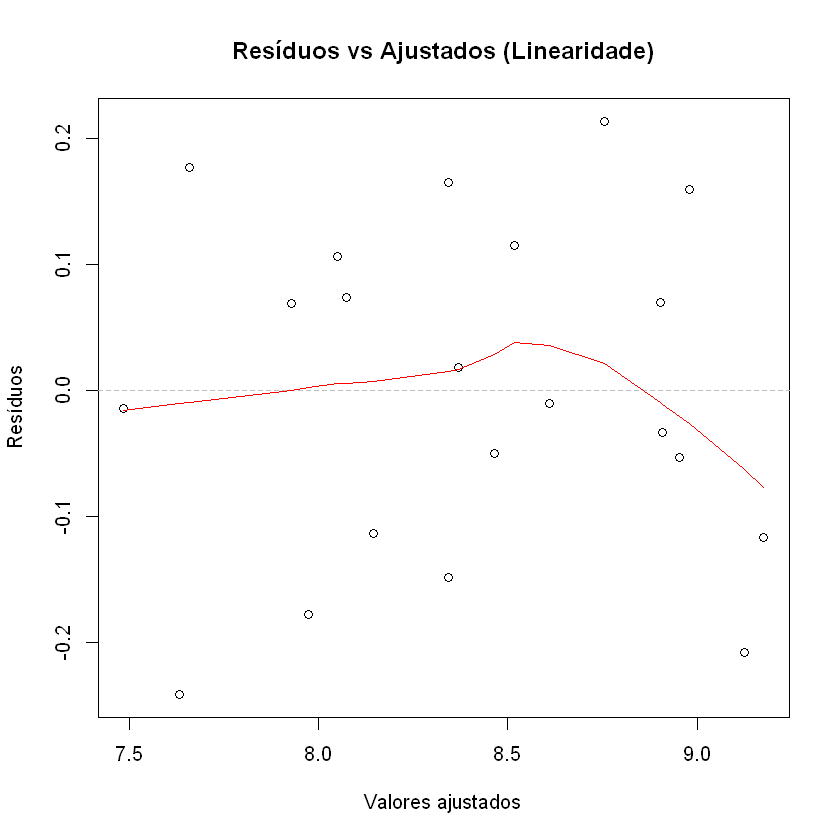

In [13]:
residuos <- residuals(modelo)
ajustados <- fitted(modelo)
residuos_student <- rstudent(modelo)
plot(ajustados, residuos,
     xlab = "Valores ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados (Linearidade)")
abline(h = 0, lty = 2, col = "gray")
# adicionar uma curva suave para ver tendências
lines(lowess(ajustados, residuos), col = "red")

Não parenta ter alguma estrutura, podemos prosseguir.

##### 3.2.2 Homocedasticidade

O gráfico seria o mesmo de antes.

Mas formalmente, pode-se fazer um teste de Breusch-Pagan.

In [14]:
library(lmtest)
bptest(modelo)

Carregando pacotes exigidos: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo
BP = 0.66704, df = 2, p-value = 0.7164


Valor-p de 0.71 não é pequeno, a hipótese da homocedasticidade não é violada, podemos prosseguir.

##### 3.2.3 Normalidade dos Erros

QQ-Plot e teste de Shapiro-Wilk


	Shapiro-Wilk normality test

data:  residuos
W = 0.96513, p-value = 0.6248


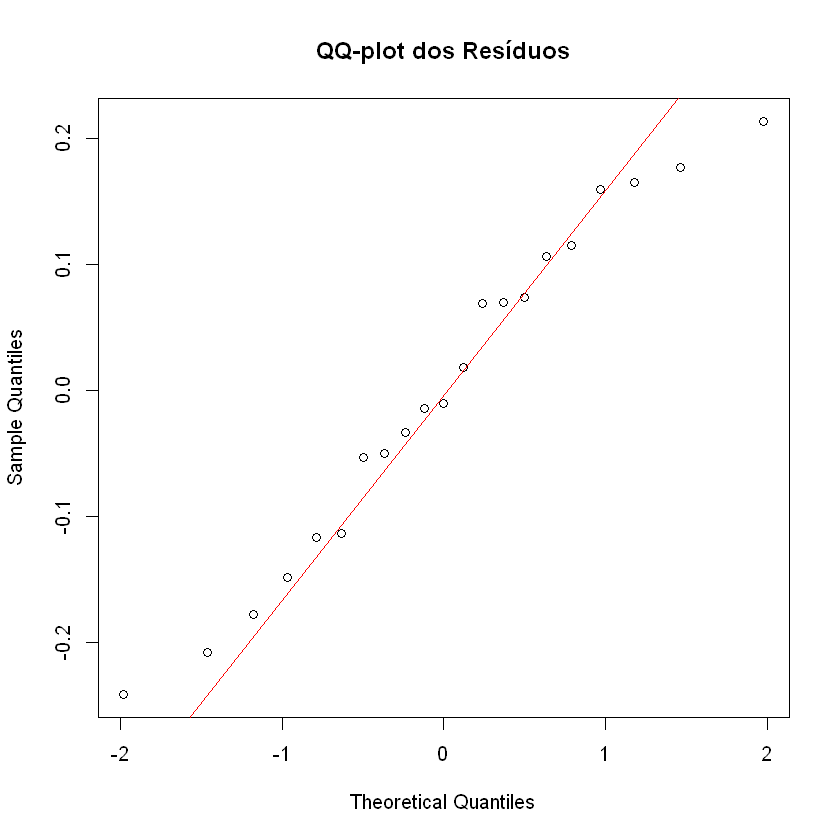

In [15]:
qqnorm(residuos, main = "QQ-plot dos Resíduos")
qqline(residuos, col = "red")

shapiro.test(residuos)

* No QQ-plot, a maioria dos pontos estão perto da reta. Pequenos desvios nas caudas são toleráveis com n = 21.

* O teste Shapiro-Wilk: $H_0$ = os dados vêm de uma distribuição normal.

Valor-p = 0.62, não rejeita $H_0$ (que afirma os dados são normalmente distribuídos)

(Claro, mesmo se valor-p fosse razoavelmente pequeno, Note que a regressão linear é robusta a desvios de normalidade especialmente para amostras não muito pequenas.)

##### 3.2.4 Independência
Como não temos a ordem de coleta, assumimos que são independentes.

---


#### 3.3 Análise de outliers e pontos influentes

##### 3.3.1 Alavanacagem (leverage)

Calculuando os valores de alavancagem ($h_{ii}$):

1          2          3          4          5          6          7 
0.16594366 0.23093569 0.12205147 0.11285555 0.21671868 0.11313763 0.16137391 
         8          9         10         11         12         13         14 
0.26292396 0.21372860 0.14760823 0.08853996 0.16250224 0.06944291 0.17113400 
        15         16         17         18         19         20         21 
0.23457457 0.07254582 0.15198053 0.09841288 0.06944291 0.05694661 0.07720020

[1] 0.2857143

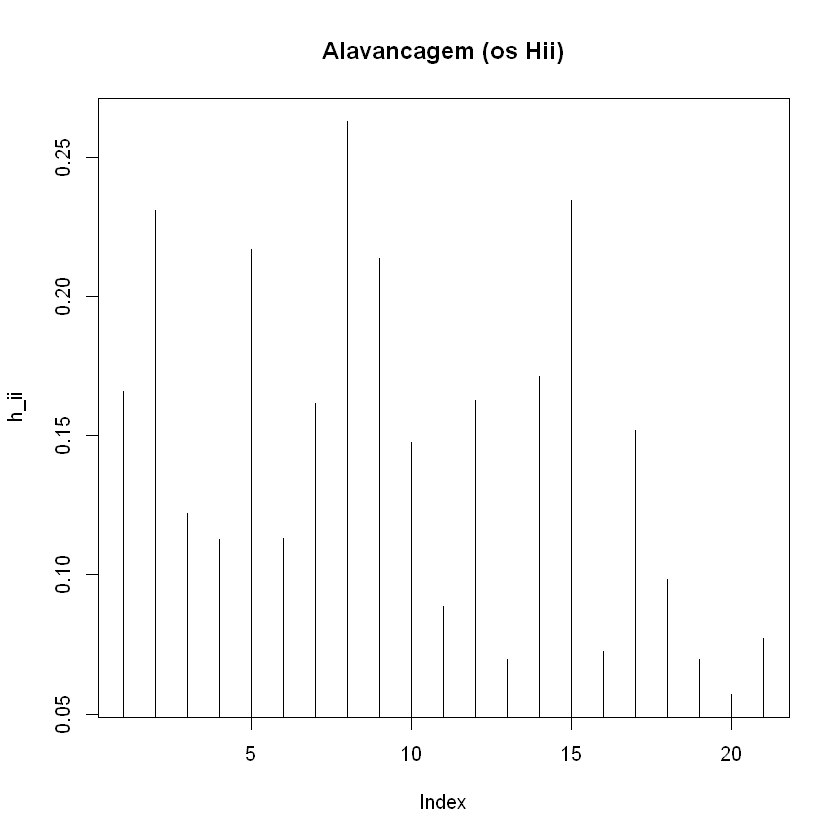

In [19]:
h <- hatvalues(modelo)
limiar_h <- 2 * length(coef(modelo)) / nrow(dados)   # 2p/n
plot(h, type = "h", col = ifelse(h > limiar_h, "red", "black"),
     main = "Alavancagem (os Hii)", ylab = "h_ii")
abline(h = limiar_h, lty = 2, col = "blue")

h
limiar_h

Não tem valores ($h_ii$) maiores que o limiar = 0.28, ou seja ninguém é considerado de alta alavancagem e merece atenção.

##### 3.3.2 Distância de Cook


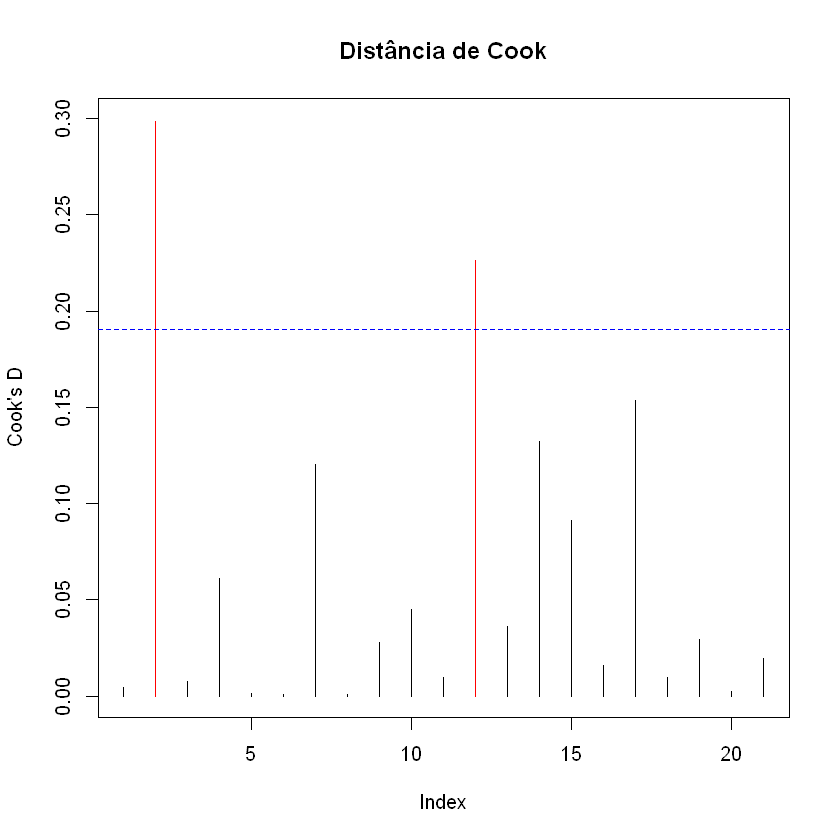

In [ ]:
cook <- cooks.distance(modelo)
limiar_cook <- 4 / nrow(dados)   # regra: se maior que 4/n
plot(cook, type = "h", col = ifelse(cook > limiar_cook, "red", "black"),
     main = "Distância de Cook", ylab = "Cook's D")
abline(h = limiar_cook, lty = 2, col = "blue")

Tem dois valores (observação 2 e 15) que são maiores que o limiar (4/21 = 0.19 ) sinalizando que são pontos influentes.

#### 3.3.3 DFFITS e DFBETAS


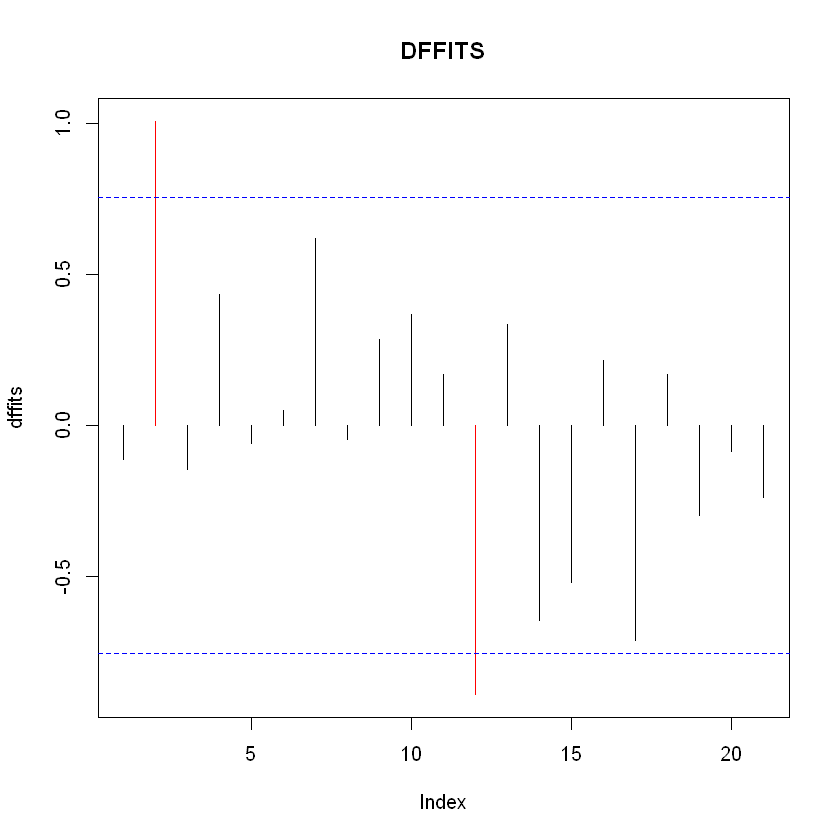

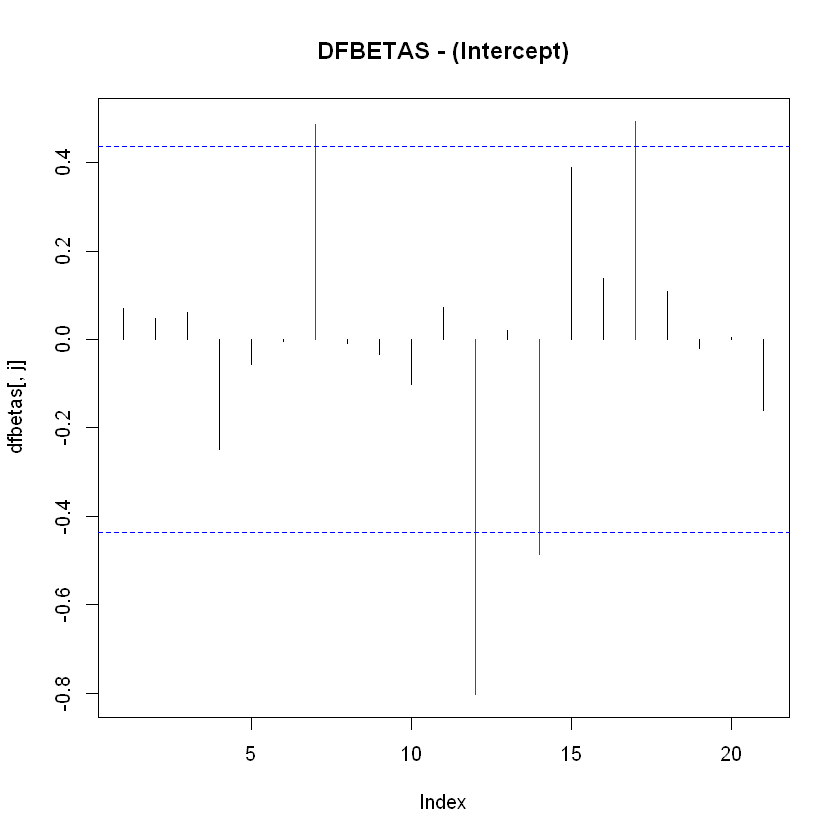

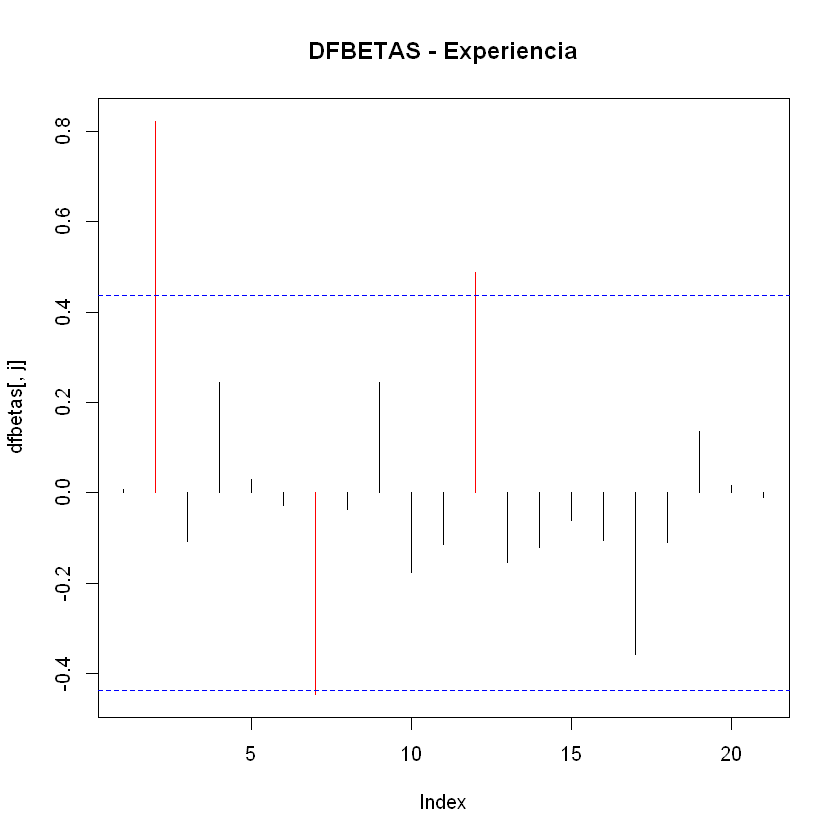

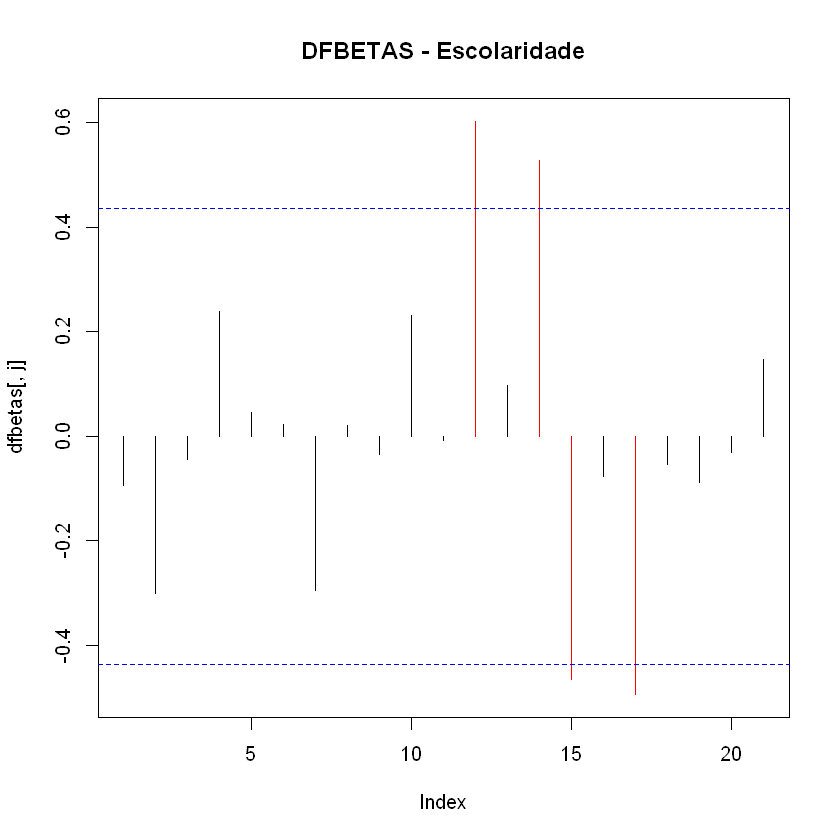

In [ ]:
dffits <- dffits(modelo)
limiar_dffits <- 2 * sqrt(length(coef(modelo)) / nrow(dados))
plot(dffits, type = "h", col = ifelse(abs(dffits) > limiar_dffits, "red", "black"),
     main = "DFFITS")
abline(h = c(-limiar_dffits, limiar_dffits), lty = 2, col = "blue")

dfbetas <- dfbetas(modelo)
limiar_dfbetas <- 2 / sqrt(nrow(dados))
# para cada coeficiente (colunas: Intercept, Experiencia, Escolaridade)
for (j in 1:ncol(dfbetas)) {
  plot(dfbetas[, j], type = "h", 
       col = ifelse(abs(dfbetas[, j]) > limiar_dfbetas, "red", "black"),
       main = paste("DFBETAS -", colnames(dfbetas)[j]))
  abline(h = c(-limiar_dfbetas, limiar_dfbetas), lty = 2, col = "blue")
}

As observações 2 e 15 possuem a distância de Cook que ultrapassa o limiar, além disso elas apresentam alta alavancagem/leverage e destacam-se em DFFits e em DFBETAS para Experiencia. Devem ser investigados.

---

In [ ]:
summary(modelo)


Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.24164 -0.11360 -0.01011  0.10610  0.21373 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   5.94336    0.16459   36.11  < 2e-16 ***
Experiencia   0.12193    0.01071   11.39 1.16e-09 ***
Escolaridade  0.14716    0.01213   12.13 4.25e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1411 on 18 degrees of freedom
Multiple R-squared:  0.9349,	Adjusted R-squared:  0.9276 
F-statistic: 129.2 on 2 and 18 DF,  p-value: 2.105e-11


#### 3.4 Testes de significância formais

Após confirmar que os pressupostos são aceitáveis, realiza-se os testes:

* Teste F global: já obtido no summary. Conclusão: Rejeita H0: $\beta_1$ = $\beta_2$ = 0， valor-p = 2.1e-11

* Testes t individuais: já no summary. todos valores-p foram bem pequneas, rejeita a hipótese de que são nulas.

Teste F parcial: serve para comparar o modelo reduzido com o modelo completo (incluindo Setor e Idade). Isso avalia se as variáveis excluídas são conjuntamente significativas.

In [ ]:
library(car)
Anova(modelo, type = "III")
modelo_full_test <- lm(LogSalario ~ Experiencia + Escolaridade + Setor + Idade, data = dados)
anova(modelo, modelo_full_test)

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),25.9742132,1,1304.0053,3.001280e-18
Experiencia,2.5836976,1,129.7115,1.164790e-09
Escolaridade,2.9303732,1,147.1160,4.246866e-10
Residuals,0.3585383,18,NA,NA


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,18,0.3585383,NA,NA,NA,NA
2,16,0.2717781,2,0.08676022,2.553855,0.1090011


Assim, pode-se dizer que:

* Para Experiência: valor-p = 1.16e-09 é muito pequeno, isso significa que remover “Experiência” piora fortemente o ajuste do modelo, mesmo mantendo “Escolaridade”.

* Para Escolaridade: valor-p = 4.24e-10 é muito pequeno, isso significa que remover Escolaridade piora fortemente o ajuste do modelo, mesmo mantendo Experiência.

Resumindo: tanto experiência quanto escolaridade apresentaram contribuição significativa para explicar a variável resposta LogSalário, controlando-se mutuamente.

Adicionalmente, o Valor-p do teste F parcial é 0.11, ou seja, as variáveis removidas (Setor, Idade) não melhoram significativamente o ajuste, justificando a parcimônia. 

---

#### 3.5 Conclusão da Etapa3 

O diagnóstico de resíduos não revelou violações graves dos pressupostos:

* A linearidade parece adequada (resíduos sem padrão)

* A hmocedasticidade é garantida (teste de Breusch-Pagan valor-p = 0.71),

* A normalidade dos resíduos é sustentável (Shapiro-Wilk p = 0.62) 

* Não há indícios de dependência. 

A análise de influência detectou pontos com leverage ligeiramente alto (obs. 2 e 15), mas D de Cook < limite. 

Os testes de significância indicam que o modelo como um todo é significativo (coeficiente de Determinação ajustado $R^2$ = 0.927) (F-global valor-p = 2.1e-11) e que ambos os preditores (Experiência e Escolaridade) são individualmente relevantes (os valores-p pequenos). 

O teste F-parcial (type III) retornou valores-p são muito pequenos, ou seja as covariáveis Experiência e Escolaridade são significativos.

E fazendo anova comparando o modelo reduzido e o modelo full, tem-se um valor-p = 0.11, confirmando que a exclusão de Setor e Idade não compromete o ajuste. 

Portanto, o modelo reduzido é apropriado.

---

## Etapa 4:
**Validação** 

Procurar a resposta da seguinte questão: **O modelo é útil para uma nova Base de dados??**

O que pode ser feito é antes de ajustar o modelo, separar um conjunto pequeno para validar depois.

1. Divisão aleatória antes de ajustar. exemplo: 70% treino e 30% teste.
2. Opções de validar o modelo:
* Reportar medidas preditivas como RMSE
* Validação cruzada (k-fold)

**Note que n=24 - 3 = 21, a amostra é pequena**

---

#### 4.1 Divisão em treino e teste


A amostra tinha 24 observações, removeu-se 3 observações absurdas sobrou 21 observações. Para validar é feita uma divisão de dados: 70% são usados para ajustar o modelo, e 30% são usados para validar.

In [20]:
# semente para reprodutibilidade
set.seed(20260512)

# número de observações
n <- nrow(dados)

# proporção para treino (70% a 80% é usual)
prop_treino <- 0.7
n_treino <- round(prop_treino * n)

# índices de treino aleatórios
indices_treino <- sample(1:n, size = n_treino, replace = FALSE)
indices_teste <- setdiff(1:n, indices_treino)

dados_treino <- dados[indices_treino, ]
dados_teste  <- dados[indices_teste, ]

#### 4.2 Reajuste do modelo para a base de treino

In [21]:
modelo_treino <- lm(LogSalario ~ Experiencia + Escolaridade, 
                    data = dados_treino)
summary(modelo_treino)


Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados_treino)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.27624 -0.09874  0.01130  0.11761  0.18334 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.09257    0.24459  24.909 1.06e-11 ***
Experiencia   0.12863    0.01404   9.161 9.16e-07 ***
Escolaridade  0.13220    0.01893   6.982 1.47e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1549 on 12 degrees of freedom
Multiple R-squared:  0.9228,	Adjusted R-squared:  0.9099 
F-statistic: 71.69 on 2 and 12 DF,  p-value: 2.121e-07


#### 4.3 Predição no conjunto de teste

In [25]:
predicoes <- predict(modelo_treino, newdata = dados_teste)
dados_teste$Pred_LogSal <- predicoes
predicoes
dados_teste

1        5        8       10       14       18 
8.850880 7.536040 8.697310 8.461415 8.050576 7.932629

,Experiencia,Escolaridade,Setor,Idade,LogSalario,Pred_LogSal
,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
1,5,16,1,38,8.874,8.850880
5,3,8,1,23,7.472,7.536040
8,11,9,0,28,8.599,8.697310
10,3,15,0,42,8.632,8.461415
14,7,8,1,39,7.796,8.050576
18,3,11,0,33,7.997,7.932629


---

##### 4.4 Métricas de erro de predição

São usadas as seugintes métricas: 

* RMSE (raiz do erro quadrático médio)
* MAE (erro absoluto médio)
* $R^2$ (Coeficiente de determinação preditivo)


In [27]:
# erros
erro <- dados_teste$LogSalario - dados_teste$Pred_LogSal

# RMSE
rmse <- sqrt(mean(erro^2))

# MAE
mae <- mean(abs(erro))

# R² preditivo (correlação ao quadrado)
r2_pred <- cor(dados_teste$LogSalario, dados_teste$Pred_LogSal)^2

# Exibir resultados
cat("RMSE:", round(rmse, 4), "\n",
    "MAE:", round(mae, 4), "\n",
    "R² preditivo:", round(r2_pred, 4), "\n")

RMSE: 0.1368 
 MAE: 0.1125 
 R² preditivo: 0.9329 


--- 

##### 4.6 Conclusão da etapa 4

Para avaliar a capacidade preditiva do modelo, a base (21 obs.) é dividida aleatoriamente em treino (15 obs.) e teste (6 obs.), com semente 20260512. 

É feito um ajuste do modelo no treino e obtivemos no teste um RMSE de 0.1368, MAE de 0.1125 e R² preditivo de 0.9329. 

Esses valores indicam que o modelo captura parte substancial da variação do log‑salário. 

Apesar do tamanho diminuto do conjunto de teste, o resultado sugere que o modelo é útil para novas observações.